In [1]:
import os
import numpy as np
import random
import pandas as pd
from glob import glob
from PIL import Image
from matplotlib import pyplot as plt
from os.path import join
from scipy import ndimage
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path
from tqdm import tqdm
from skimage.morphology import skeletonize

In [2]:
nnUNet_raw = "/home/ultrai/UltrAi/knee_us_segmentation/data/nnUNet_raw"
nnUNet_results = "/home/ultrai/UltrAi/knee_us_segmentation/data/nnUNet_results"
orig_datasets = "/home/ultrai/UltrAi/knee_us_segmentation/data/raw_data/datasets"
resolution_csv = "/home/ultrai/UltrAi/knee_us_segmentation/data/pixel_physical_resolution.csv"

def get_dataset_name(nnUNet_raw, dataset_id):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [dataset_name for dataset_name in os.listdir(nnUNet_raw) if dataset_name.startswith(f"Dataset{dataset_id}") and os.path.isdir(join(nnUNet_raw, dataset_name))]
    assert len(dataset_name) == 1, f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1"
    return dataset_name[0]

In [3]:
def get_bounding_box(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0 or ys.size == 0:
        return 0, 0, mask.shape[1], mask.shape[0]

    x_min, x_max = xs.min(), xs.max()
    y_min, y_max = ys.min(), ys.max()
    crop_w = x_max - x_min + 1
    crop_h = y_max - y_min + 1
    return x_min, y_min, crop_w, crop_h

def binarize_mask(mask):
    return (mask > 0).astype(np.uint8)

def compute_dice(mask_a, mask_b):
    mask_a = binarize_mask(mask_a)
    mask_b = binarize_mask(mask_b)
    intersection = np.logical_and(mask_a, mask_b).sum()
    denom = mask_a.sum() + mask_b.sum()
    if denom == 0:
        return 1.0
    return (2.0 * intersection) / denom

def get_surface(mask):
    mask = binarize_mask(mask).astype(bool)
    if not mask.any():
        return mask
    eroded = ndimage.binary_erosion(mask)
    return np.logical_xor(mask, eroded)

def compute_masd(mask_a, mask_b):
    mask_a = binarize_mask(mask_a)
    mask_b = binarize_mask(mask_b)

    if not mask_a.any() and not mask_b.any():
        return 0.0
    if not mask_a.any() or not mask_b.any():
        return np.nan

    surf_a = get_surface(mask_a)
    surf_b = get_surface(mask_b)
    dt_a = ndimage.distance_transform_edt(~surf_a)
    dt_b = ndimage.distance_transform_edt(~surf_b)
    dists_a_to_b = dt_b[surf_a]
    dists_b_to_a = dt_a[surf_b]
    return float(np.concatenate([dists_a_to_b, dists_b_to_a]).mean())

def compute_hd95(mask_a, mask_b):
    mask_a = binarize_mask(mask_a)
    mask_b = binarize_mask(mask_b)

    if not mask_a.any() and not mask_b.any():
        return 0.0
    if not mask_a.any() or not mask_b.any():
        return np.nan

    surf_a = get_surface(mask_a)
    surf_b = get_surface(mask_b)
    dt_a = ndimage.distance_transform_edt(~surf_a)
    dt_b = ndimage.distance_transform_edt(~surf_b)
    dists_a_to_b = dt_b[surf_a]
    dists_b_to_a = dt_a[surf_b]
    return float(np.percentile(np.concatenate([dists_a_to_b, dists_b_to_a]), 95))

def compute_masd_in_mm(masd_px, px_per_mm):
    if px_per_mm is None or px_per_mm == 0 or np.isnan(masd_px):
        return np.nan
    return masd_px / px_per_mm

def compute_hd95_in_mm(hd95_px, px_per_mm):
    if px_per_mm is None or px_per_mm == 0 or np.isnan(hd95_px):
        return np.nan
    return hd95_px / px_per_mm

def keep_largest_component(mask):
    mask = binarize_mask(mask).astype(bool)
    if not mask.any():
        return mask.astype(np.uint8)
    labeled, num = ndimage.label(mask)
    if num <= 1:
        return mask.astype(np.uint8)
    counts = np.bincount(labeled.ravel())
    counts[0] = 0
    largest = counts.argmax()
    return (labeled == largest).astype(np.uint8)

def load_pixels_per_mm_map(resolution_csv):
    df = pd.read_csv(resolution_csv)
    return {int(row['dataset_id']): float(row['scale(pixels/mm)']) for _, row in df.iterrows()}

def compute_skeleton_length_mm(skeleton, scale_x, scale_y):
    coords = np.column_stack(np.nonzero(skeleton))
    visited = set()
    length_mm = 0.0

    for y, x in coords:
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0:
                    continue
                ny, nx = y + dy, x + dx
                if (
                    0 <= ny < skeleton.shape[0]
                    and 0 <= nx < skeleton.shape[1]
                    and skeleton[ny, nx]
                    and ((ny, nx), (y, x)) not in visited
                ):
                    dist = np.sqrt((dy * scale_y) ** 2 + (dx * scale_x) ** 2)
                    length_mm += dist
                    visited.add(((y, x), (ny, nx)))
    return length_mm

def compute_geodesic_skeleton_length_mm(skeleton, scale_x, scale_y):
    coords = np.column_stack(np.nonzero(skeleton))
    if len(coords) == 0:
        return np.nan

    coord_to_idx = {tuple(coord): i for i, coord in enumerate(coords)}
    rows, cols, weights = [], [], []
    degrees = np.zeros(len(coords), dtype=int)

    for i, (y, x) in enumerate(coords):
        for dy in [-1, 0, 1]:
            for dx in [-1, 0, 1]:
                if dy == 0 and dx == 0:
                    continue
                neighbor = (y + dy, x + dx)
                j = coord_to_idx.get(neighbor)
                if j is None:
                    continue
                degrees[i] += 1
                if j > i:
                    dist = np.sqrt((dy * scale_y) ** 2 + (dx * scale_x) ** 2)
                    rows.extend([i, j])
                    cols.extend([j, i])
                    weights.extend([dist, dist])

    graph = csr_matrix((weights, (rows, cols)), shape=(len(coords), len(coords)))
    endpoints = np.where(degrees == 1)[0]

    if len(endpoints) >= 2:
        dists = shortest_path(graph, directed=False, indices=endpoints)
        endpoint_dists = dists[:, endpoints]
        finite = endpoint_dists[np.isfinite(endpoint_dists)]
    else:
        dists = shortest_path(graph, directed=False)
        finite = dists[np.isfinite(dists)]

    finite = finite[finite > 0]
    if finite.size == 0:
        return np.nan
    return float(finite.max())

def compute_cartilage_thickness(mask, px_per_mm, length_mode="geodesic"):
    binary_mask = binarize_mask(mask)
    if not binary_mask.any() or px_per_mm is None or px_per_mm == 0:
        return np.nan
    scale_mm = 1.0 / px_per_mm
    skeleton = skeletonize(binary_mask.astype(bool))
    if length_mode == "geodesic":
        length_mm = compute_geodesic_skeleton_length_mm(skeleton, scale_mm, scale_mm)
    elif length_mode == "edge_sum":
        length_mm = compute_skeleton_length_mm(skeleton, scale_mm, scale_mm)
    else:
        raise ValueError(f"Unknown length_mode: {length_mode}")
    if length_mm == 0:
        return np.nan
    area_mm2 = binary_mask.sum() * (scale_mm ** 2)
    return area_mm2 / length_mm

def format_metric_text(dice, masd_px, masd_mm, gt_thickness_mm=None, pred_thickness_mm=None, gt_thickness_edge_mm=None, pred_thickness_edge_mm=None):
    masd_px_text = 'nan' if np.isnan(masd_px) else f'{masd_px:.2f}'
    masd_mm_text = 'nan' if np.isnan(masd_mm) else f'{masd_mm:.2f}'
    lines = [
        f'Dice: {dice * 100:.2f}%',
        f'MASD: {masd_px_text} px',
        f'MASD: {masd_mm_text} mm',
    ]
    if gt_thickness_mm is not None:
        gt_text = 'nan' if np.isnan(gt_thickness_mm) else f'{gt_thickness_mm:.2f}'
        lines.append(f'GT thickness: {gt_text} mm')
    if pred_thickness_mm is not None:
        pred_text = 'nan' if np.isnan(pred_thickness_mm) else f'{pred_thickness_mm:.2f}'
        lines.append(f'Pred thickness (geo): {pred_text} mm')
    if gt_thickness_edge_mm is not None:
        gt_edge_text = 'nan' if np.isnan(gt_thickness_edge_mm) else f'{gt_thickness_edge_mm:.2f}'
        lines.append(f'GT thickness (edge): {gt_edge_text} mm')
    if pred_thickness_edge_mm is not None:
        pred_edge_text = 'nan' if np.isnan(pred_thickness_edge_mm) else f'{pred_thickness_edge_mm:.2f}'
        lines.append(f'Pred thickness (edge): {pred_edge_text} mm')
    return '\n'.join(lines)

def plot_prediction_comparison(img, gt, pred, orig_image, orig_gt, orig_pred, raw_metric_text, orig_metric_text):
    plt.figure(figsize=(20, 8))

    ax = plt.subplot(1, 2, 1)
    ax.imshow(img, cmap="gray")
    ax.contour(gt, levels=[0.5], colors="yellow")
    ax.contour(pred, levels=[0.5], colors="red", linewidths=1.25)
    ax.text(
        0.02,
        0.02,
        raw_metric_text,
        transform=ax.transAxes,
        fontsize=10,
        family="monospace",
        color="white",
        va="bottom",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="black", edgecolor="white", linewidth=1.0, alpha=0.8),
    )
    ax.axis("off")

    ax = plt.subplot(1, 2, 2)
    ax.imshow(orig_image, cmap="gray")
    ax.contour(orig_gt, levels=[0.5], colors="yellow")
    ax.contour(orig_pred, levels=[0.5], colors="red", linewidths=1.25)
    ax.text(
        0.02,
        0.03,
        orig_metric_text,
        transform=ax.transAxes,
        fontsize=10,
        family="monospace",
        color="white",
        va="bottom",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="black", edgecolor="white", linewidth=1.0, alpha=0.8),
    )
    ax.axis("off")

    plt.show()

def estimate_mask_transform(raw_mask, orig_mask):
    x_raw, y_raw, w_raw, h_raw = get_bounding_box(raw_mask)
    x_orig, y_orig, w_orig, h_orig = get_bounding_box(orig_mask)

    if w_raw == 0 or h_raw == 0:
        return {
            "scale_x": 1.0,
            "scale_y": 1.0,
            "tx": 0.0,
            "ty": 0.0,
            "raw_bbox": (x_raw, y_raw, w_raw, h_raw),
            "orig_bbox": (x_orig, y_orig, w_orig, h_orig),
        }

    scale_x = w_orig / w_raw
    scale_y = h_orig / h_raw
    tx = x_orig - scale_x * x_raw
    ty = y_orig - scale_y * y_raw
    return {
        "scale_x": scale_x,
        "scale_y": scale_y,
        "tx": tx,
        "ty": ty,
        "raw_bbox": (x_raw, y_raw, w_raw, h_raw),
        "orig_bbox": (x_orig, y_orig, w_orig, h_orig),
    }

def apply_mask_transform(mask, transform, out_w, out_h):
    if isinstance(mask, np.ndarray):
        mask = Image.fromarray(mask.astype(np.uint8))

    scaled_w = max(1, int(round(mask.size[0] * transform["scale_x"])))
    scaled_h = max(1, int(round(mask.size[1] * transform["scale_y"])))
    resized = mask.resize((scaled_w, scaled_h), resample=Image.NEAREST)
    resized_arr = np.array(resized)
    canvas = np.zeros((out_h, out_w), dtype=np.uint8)

    x0 = int(round(transform["tx"]))
    y0 = int(round(transform["ty"]))
    x1 = max(0, x0)
    y1 = max(0, y0)
    x2 = min(out_w, x0 + scaled_w)
    y2 = min(out_h, y0 + scaled_h)

    if x1 >= x2 or y1 >= y2:
        return canvas

    src_x1 = x1 - x0
    src_y1 = y1 - y0
    src_x2 = src_x1 + (x2 - x1)
    src_y2 = src_y1 + (y2 - y1)
    canvas[y1:y2, x1:x2] = resized_arr[src_y1:src_y2, src_x1:src_x2]
    return canvas


In [4]:
ignore_ids = [
    "Nike_Brian___NIKE_S962_T4_R_CAR_3_1562",
    "Nike_Brian___NIKE_S975_T4_L_CAR_2_752",
    "Nike_XC_Jamil___NIKE_S129_T0_L_CAR_3_1119",
    "Nike_XC_Jamil___NIKE_S129_T0_L_CAR_1_895",
    "Nike_Brian___NIKE_S951_T4_R_CAR_3_1149",
    "20251103201014____frame_73_042",
    "20251103200953____frame_8_254",
    "20251103200953____frame_11_229",
    "20251103200953____frame_46_040",
    "20251103200953____frame_48_354",
    "20251103200953____frame_49_274",
    "20251103200953____frame_50_063",
    "20251103201014____frame_2_366",
    "20251103201014____frame_3_048",
    "20251103201014____frame_4_003",
    "20251103201014____frame_45_257",
    "20251103201014____frame_46_317",
    "20251103201014____frame_47_263",
    "20251103201014____frame_48_152",
    "20251103201014____frame_67_265",
    "20251103201014____frame_68_090",
    "20251103201014____frame_69_101",
    "20251103201014____frame_70_009",
    "20251103201014____frame_71_148",
    "20251103201014____frame_72_202",
    "20251103201014____frame_73_042",
    "20251103201014____frame_74_243",
    "20251103201014____frame_75_231",
    "20251103201014____frame_76_021",
    "20251103201043____frame_7_301",
    "20251103201043____frame_8_099",
    ""
]

Found 234 files in models/MonoUNetE123V2GatedDA/Dataset073_GE_LE/fold_0/test/Dataset070_Clarius_L15/preds


  0%|          | 0/234 [00:00<?, ?it/s]

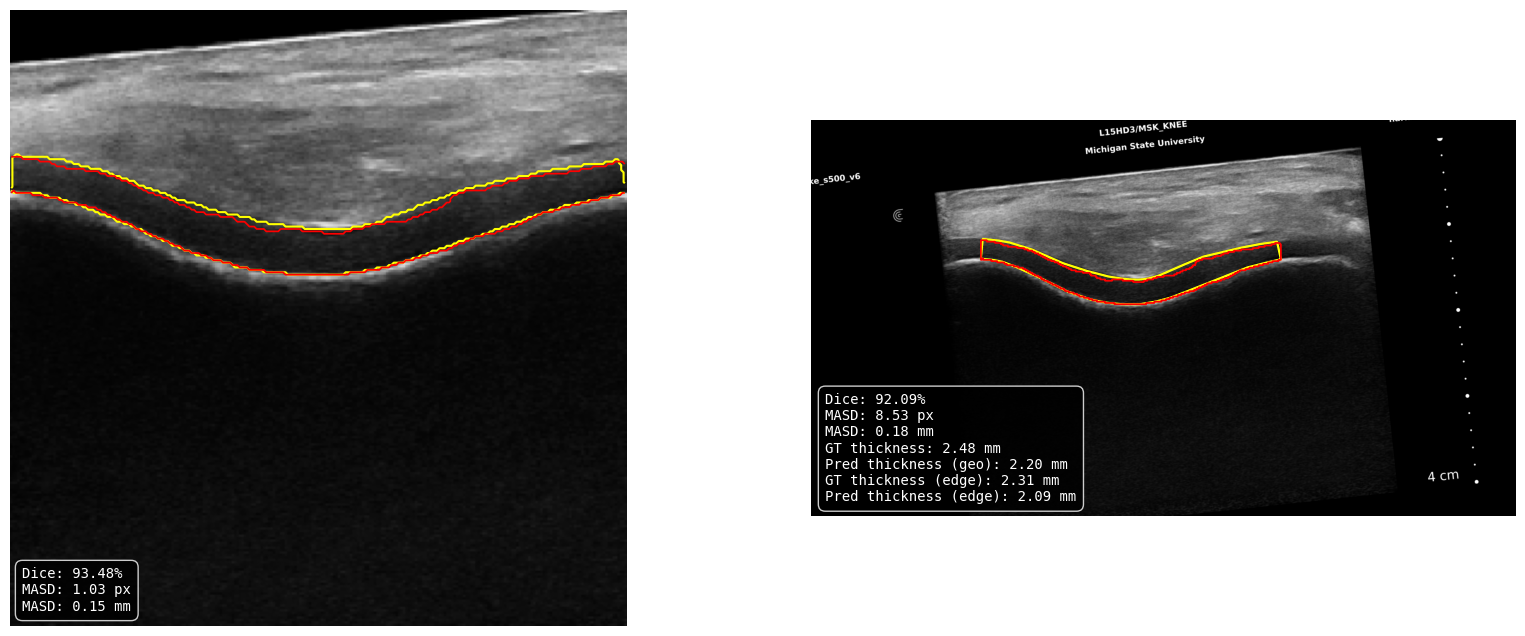

  0%|          | 0/234 [00:06<?, ?it/s]

Saved results to models/MonoUNetE123V2GatedDA/Dataset073_GE_LE/fold_0/test/results_Dataset070_Clarius_L15.csv


In [5]:
debug = True

train_dataset_id = 73
test_dataset_id = 70
fold = 0

train_dataset = get_dataset_name(nnUNet_raw, train_dataset_id)
test_dataset = get_dataset_name(nnUNet_raw, test_dataset_id)
# model = "UNext"
model = "MonoUNetE123V2GatedDA"

split = "Ts" if test_dataset_id == 79 else "Tr"

model_dir = f"models/{model}/{train_dataset}/fold_{fold}"
preds_dir = f"{model_dir}/test/{test_dataset}/preds"
save_path = f"{model_dir}/test/results_{test_dataset}.csv"

images_dir = f"{nnUNet_raw}/{test_dataset}/images{split}"
gt_dir = f"{nnUNet_raw}/{test_dataset}/labels{split}"

px_per_mm_map = load_pixels_per_mm_map(resolution_csv)

files = glob(join(preds_dir, "*.png"))
print(f"Found {len(files)} files in {preds_dir}")

random.shuffle(files)
for pred_path in tqdm(files):
    fn = os.path.basename(pred_path)
    if fn in ignore_ids:
        continue

    image_path = f"{images_dir}/{os.path.basename(pred_path)}"
    image_path = image_path.replace(".png", "_0000.png")
    gt_path = f"{gt_dir}/{os.path.basename(pred_path)}"
    
    if test_dataset_id == 79:
        orig_folder = "KneeUS_Ilker"
        orig_fn = fn
    else:
        orig_folder, orig_fn = os.path.basename(pred_path).split("___")
    orig_fn = orig_fn.rsplit("_", 1)[0]
    orig_image_path = glob(f"{orig_datasets}/{orig_folder}/images/{orig_fn}*")[0]
    orig_gt_path = glob(f"{orig_datasets}/{orig_folder}/masks/{orig_fn}*")[0]
    
    img = np.array(Image.open(image_path))
    gt = binarize_mask(np.array(Image.open(gt_path)))
    pred = np.array(Image.open(pred_path))
    gt_in_pred_space = np.array(Image.fromarray(gt.astype(np.uint8)).resize((pred.shape[1], pred.shape[0]), resample=Image.NEAREST))
    img = np.array(Image.fromarray(img.astype(np.uint8)).resize((pred.shape[1], pred.shape[0]), resample=Image.NEAREST))

    pred = binarize_mask(pred)

    orig_image = np.array(Image.open(orig_image_path).convert("L"))
    orig_gt = binarize_mask(np.array(Image.open(orig_gt_path)))

    transform = estimate_mask_transform(gt_in_pred_space, orig_gt)
    orig_pred = apply_mask_transform(pred, transform, orig_image.shape[1], orig_image.shape[0])

    orig_px_per_mm = px_per_mm_map[test_dataset_id]
    raw_px_per_mm = orig_px_per_mm / np.sqrt(transform["scale_x"] * transform["scale_y"])

    dice_raw = compute_dice(pred, gt_in_pred_space)
    hd95_raw_px = compute_hd95(pred, gt_in_pred_space)
    hd95_raw_mm = compute_hd95_in_mm(hd95_raw_px, raw_px_per_mm)
    masd_raw_px = compute_masd(pred, gt_in_pred_space)
    masd_raw_mm = compute_masd_in_mm(masd_raw_px, raw_px_per_mm)
    dice_orig = compute_dice(orig_pred, orig_gt)
    hd95_orig_px = compute_hd95(orig_pred, orig_gt)
    hd95_orig_mm = compute_hd95_in_mm(hd95_orig_px, orig_px_per_mm)
    masd_orig_px = compute_masd(orig_pred, orig_gt)
    masd_orig_mm = compute_masd_in_mm(masd_orig_px, orig_px_per_mm)
    gt_thickness_orig_mm = compute_cartilage_thickness(orig_gt, orig_px_per_mm, length_mode="geodesic")
    pred_thickness_orig_mm = compute_cartilage_thickness(orig_pred, orig_px_per_mm, length_mode="geodesic")
    gt_thickness_orig_edge_mm = compute_cartilage_thickness(orig_gt, orig_px_per_mm, length_mode="edge_sum")
    pred_thickness_orig_edge_mm = compute_cartilage_thickness(orig_pred, orig_px_per_mm, length_mode="edge_sum")

    row = {
        "image_id": os.path.splitext(fn)[0],
        "dice": round(dice_orig * 100, 2),
        "hd95": round(hd95_orig_mm, 2) if not np.isnan(hd95_orig_mm) else np.nan,
        "masd": round(masd_orig_mm, 2) if not np.isnan(masd_orig_mm) else np.nan,
    }

    if debug:
        raw_metric_text = format_metric_text(dice_raw, masd_raw_px, masd_raw_mm)
        orig_metric_text = format_metric_text(dice_orig, masd_orig_px, masd_orig_mm, gt_thickness_orig_mm, pred_thickness_orig_mm, gt_thickness_orig_edge_mm, pred_thickness_orig_edge_mm)
        plot_prediction_comparison(img, gt_in_pred_space, pred, orig_image, orig_gt, orig_pred, raw_metric_text, orig_metric_text)
        break

print(f"Saved results to {save_path}")

In [78]:
import pingouin as pg

LEFT_LEG_FORMATS = {"l", "l1", "l2", "l3"}
RIGHT_LEG_FORMATS = {"r", "r1", "r2", "r3"}
INJ_LEG_FORMATS = {"inj", "injured"}
UNINJ_LEG_FORMATS = {"uninj", "noninj", "non-inj", "uninjured", "noninjured", "non-injured"}


def get_subject_id(img_id):
    img_id = os.path.basename(img_id).rsplit('.', 1)[0]
    if '___' in img_id:
        dataset, subject_part = img_id.rsplit('___', 1)
    else:
        dataset, subject_part = '', img_id

    if 'nike' in subject_part.lower() or 'mri' in subject_part.lower() or subject_part.lower().startswith('acl'):
        subject_key = '_'.join(subject_part.split('_', 2)[:2])
    else:
        subject_key = subject_part.split('_', 1)[0]

    return '___'.join([dataset, subject_key]) if dataset else subject_key


def separate_subjects(img_ids):
    subject_ids = sorted({get_subject_id(img_id) for img_id in img_ids})
    return subject_ids


def get_case_prefix(img_id):
    img_id = os.path.basename(img_id).rsplit('.', 1)[0]
    parts = img_id.rsplit('_', 2)
    if len(parts) == 3 and parts[-2].isdigit() and parts[-1].isdigit():
        return parts[0]
    if len(parts) == 2 and parts[-1].isdigit():
        return parts[0]
    return img_id


def get_case_label(img_id):
    tokens = [token.lower() for token in get_case_prefix(img_id).split('_')]
    for token in tokens:
        if token in INJ_LEG_FORMATS:
            return 'inj'
    for token in tokens:
        if token in UNINJ_LEG_FORMATS:
            return 'non-inj'
    for token in tokens:
        if token in LEFT_LEG_FORMATS:
            return 'left'
    for token in tokens:
        if token in RIGHT_LEG_FORMATS:
            return 'right'
    return 'unknown'


def build_case_df(outcomes_df, subject_ids):
    case_rows = []
    for subject_id in subject_ids:
        subject_outcomes = outcomes_df[outcomes_df['subject_id'] == subject_id].copy()
        if len(subject_outcomes) == 0:
            continue

        for case_prefix, sample_rows in subject_outcomes.groupby('case_prefix', sort=True):
            if len(sample_rows) == 0:
                continue
            case_rows.append({
                'subject_id': subject_id,
                'case_label': sample_rows['case_label'].iloc[0],
                'case_prefix': case_prefix,
                'gt_thickness': sample_rows['gt_thickness'].mean(),
                'pred_thickness': sample_rows['pred_thickness'].mean(),
                'gt_echo_intensity': sample_rows['gt_echo_intensity'].mean(),
                'pred_echo_intensity': sample_rows['pred_echo_intensity'].mean(),
            })

    return pd.DataFrame(case_rows)


def compute_icc2k(case_prefixes, pred, gt):
    icc_df = pd.DataFrame({
        'subject': np.concatenate([case_prefixes, case_prefixes]),
        'method': ['manual'] * len(case_prefixes) + ['auto'] * len(case_prefixes),
        'value': np.concatenate([gt, pred]),
    })
    icc_result = pg.intraclass_corr(data=icc_df, targets='subject', raters='method', ratings='value')
    icc_row = icc_result.query("Type == 'ICC2k'").iloc[0]
    ci_low, ci_high = icc_row['CI95']
    return icc_row['ICC'], ci_low, ci_high


def get_outliers_outside_loa(case_prefixes, pred, gt):
    pred = np.array(pred)
    gt = np.array(gt)
    case_prefixes = np.array(case_prefixes)
    valid = (~np.isnan(gt)) & (~np.isnan(pred)) & (gt != 0)
    pred = pred[valid]
    gt = gt[valid]
    case_prefixes = case_prefixes[valid]

    mean = np.mean([pred, gt], axis=0)
    diff = gt - pred
    diff_pct = diff / gt * 100
    mean_diff_pct = np.mean(diff_pct)
    std_diff_pct = np.std(diff_pct, ddof=1)
    upper_loa_pct = mean_diff_pct + 1.96 * std_diff_pct
    lower_loa_pct = mean_diff_pct - 1.96 * std_diff_pct

    outlier_mask = (diff_pct < lower_loa_pct) | (diff_pct > upper_loa_pct)
    return pd.DataFrame({
        'case_prefix': case_prefixes[outlier_mask],
        'mean': mean[outlier_mask],
        'manual': gt[outlier_mask],
        'auto': pred[outlier_mask],
        'diff': diff[outlier_mask],
        'diff_pct': diff_pct[outlier_mask],
    }).sort_values('diff_pct', key=np.abs, ascending=False)


def plot_bland_altman(ax, case_prefixes, pred, gt, label):
    pred = np.array(pred)
    gt = np.array(gt)
    case_prefixes = np.array(case_prefixes)
    valid = (~np.isnan(gt)) & (~np.isnan(pred)) & (gt != 0)
    pred = pred[valid]
    gt = gt[valid]
    case_prefixes = case_prefixes[valid]

    mean = np.mean([pred, gt], axis=0)
    diff = gt - pred
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)

    diff_pct = (gt - pred) / gt * 100
    mean_diff_pct = np.mean(diff_pct)
    std_diff_pct = np.std(diff_pct, ddof=1)

    upper_loa = mean_diff + 1.96 * std_diff
    lower_loa = mean_diff - 1.96 * std_diff
    upper_loa_pct = mean_diff_pct + 1.96 * std_diff_pct
    lower_loa_pct = mean_diff_pct - 1.96 * std_diff_pct

    units = 'mm' if 'thickness' in label else 'a.u.'
    ax.scatter(mean, diff_pct, alpha=0.6)
    ax.axhline(y=mean_diff_pct, color='r', linestyle='--', label=f'Mean: {mean_diff_pct:.2f}% ({mean_diff:.3f} {units})')
    ax.axhline(y=upper_loa_pct, color='g', linestyle='--', label=f'95% Upper LOA: {upper_loa_pct:.2f}% ({upper_loa:.3f} {units})')
    ax.axhline(y=lower_loa_pct, color='g', linestyle='--', label=f'95% Lower LOA: {lower_loa_pct:.2f}% ({lower_loa:.3f} {units})')
    ax.set_xlabel(f'Mean of Manual and Automated {label.title()} ({units})')
    ax.set_ylabel('Manual - Automated (%)')
    ax.set_title(f'Average cartilage {label.lower()}')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-19, 19)
    ax.legend(loc='lower center', ncol=1, bbox_to_anchor=(0.5, -0.65))


,subject_id,case_label,case_prefix,gt_thickness,pred_thickness,gt_echo_intensity,pred_echo_intensity
0,Nike_Arjun_clarius_auto___Nike_s500,right,Nike_Arjun_clarius_auto___Nike_s500_v6_CAR_R1_092,2.4848,2.287233,34.2869,33.298200
1,Nike_Arjun_clarius_auto___Nike_s500,right,Nike_Arjun_clarius_auto___Nike_s500_v6_CAR_R2_077,2.7418,2.467167,39.3247,36.990267
2,Nike_Arjun_clarius_auto___Nike_s500,right,Nike_Arjun_clarius_auto___Nike_s500_v6_CAR_R3_125,2.6500,2.422933,35.5497,32.979400
3,Nike_Arjun_clarius_auto___Nike_s501,right,Nike_Arjun_clarius_auto___Nike_s501_v6_CAR_R1_176,2.0692,1.871233,42.3019,40.037267
4,Nike_Arjun_clarius_auto___Nike_s501,right,Nike_Arjun_clarius_auto___Nike_s501_v6_CAR_R2_119,2.0361,1.946567,38.0508,37.320667


Saved Bland-Altman plot to models/MonoUNetE123V2GatedDA/Dataset073_GE_LE/cartilage_outcomes_bland_altman_Dataset070_Clarius_L15.svg


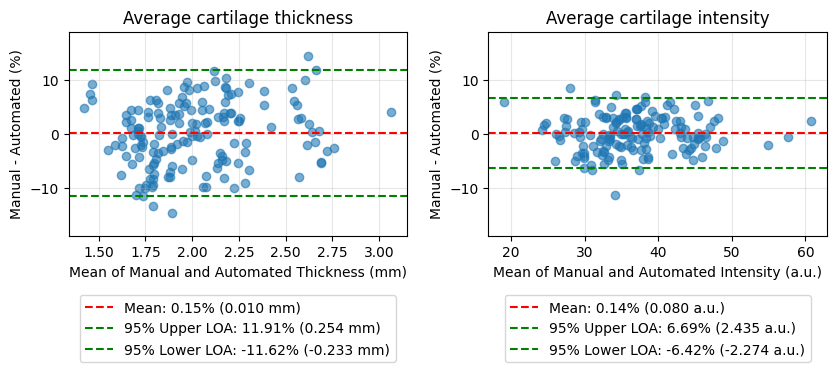

Thickness ICC(2,k): 0.961 [0.950, 0.970]
Intensity ICC(2,k): 0.992 [0.990, 0.990]


In [79]:
fold_outcomes = []
if test_dataset == train_dataset:
    outcomes_csv_path = f"models/{model}/{train_dataset}/cartilage_outcomes_{test_dataset}.csv"
    if os.path.exists(outcomes_csv_path):
        fold_df = pd.read_csv(outcomes_csv_path)
        fold_df = fold_df[~fold_df['image_id'].isin(ignore_ids)].copy()
        fold_outcomes.append(fold_df)
else:
    for current_fold in range(3):
        outcomes_csv_path = f"models/{model}/{train_dataset}/fold_{current_fold}/test/cartilage_outcomes_{test_dataset}.csv"
        if not os.path.exists(outcomes_csv_path):
            continue
        fold_df = pd.read_csv(outcomes_csv_path)
        fold_df = fold_df[~fold_df['image_id'].isin(ignore_ids)].copy()
        fold_outcomes.append(fold_df)

outcomes_df = pd.concat(fold_outcomes, ignore_index=True)
outcomes_df = outcomes_df.groupby('image_id', as_index=False)[['gt_thickness', 'pred_thickness', 'gt_echo_intensity', 'pred_echo_intensity']].mean()
outcomes_df['subject_id'] = outcomes_df['image_id'].map(get_subject_id)
outcomes_df['case_label'] = outcomes_df['image_id'].map(get_case_label)
outcomes_df['case_prefix'] = outcomes_df['image_id'].map(get_case_prefix)

subject_ids = separate_subjects(outcomes_df['image_id'].tolist())
case_df = build_case_df(outcomes_df, subject_ids)
display(case_df.head())

fig, axes = plt.subplots(1, 2, figsize=(8.5, 5))
plot_bland_altman(axes[0], case_df['case_prefix'].values, case_df['pred_thickness'].values, case_df['gt_thickness'].values, 'thickness')
plot_bland_altman(axes[1], case_df['case_prefix'].values, case_df['pred_echo_intensity'].values, case_df['gt_echo_intensity'].values, 'intensity')
plt.tight_layout()
save_path = f"models/{model}/{train_dataset}/cartilage_outcomes_bland_altman_{test_dataset}.svg"
plt.savefig(save_path, dpi=300, format="svg", bbox_inches="tight")
print(f"Saved Bland-Altman plot to {save_path}")
plt.show()

thickness_icc, thickness_icc_low, thickness_icc_high = compute_icc2k(case_df['case_prefix'].values, case_df['pred_thickness'].values, case_df['gt_thickness'].values)
intensity_icc, intensity_icc_low, intensity_icc_high = compute_icc2k(case_df['case_prefix'].values, case_df['pred_echo_intensity'].values, case_df['gt_echo_intensity'].values)

print(f"Thickness ICC(2,k): {thickness_icc:.3f} [{thickness_icc_low:.3f}, {thickness_icc_high:.3f}]")
print(f"Intensity ICC(2,k): {intensity_icc:.3f} [{intensity_icc_low:.3f}, {intensity_icc_high:.3f}]")

thickness_outliers = get_outliers_outside_loa(case_df['case_prefix'].values, case_df['pred_thickness'].values, case_df['gt_thickness'].values)
intensity_outliers = get_outliers_outside_loa(case_df['case_prefix'].values, case_df['pred_echo_intensity'].values, case_df['gt_echo_intensity'].values)


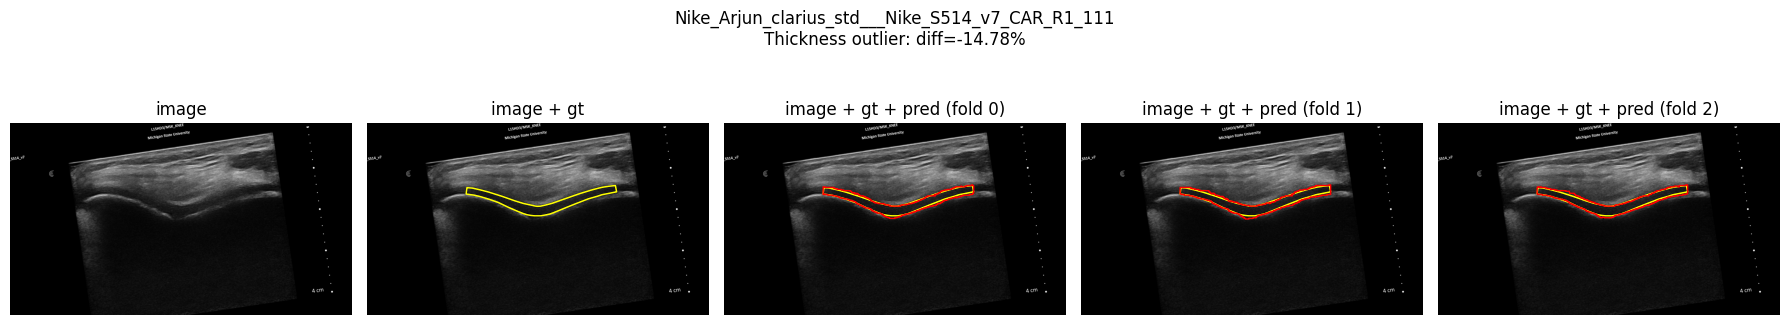

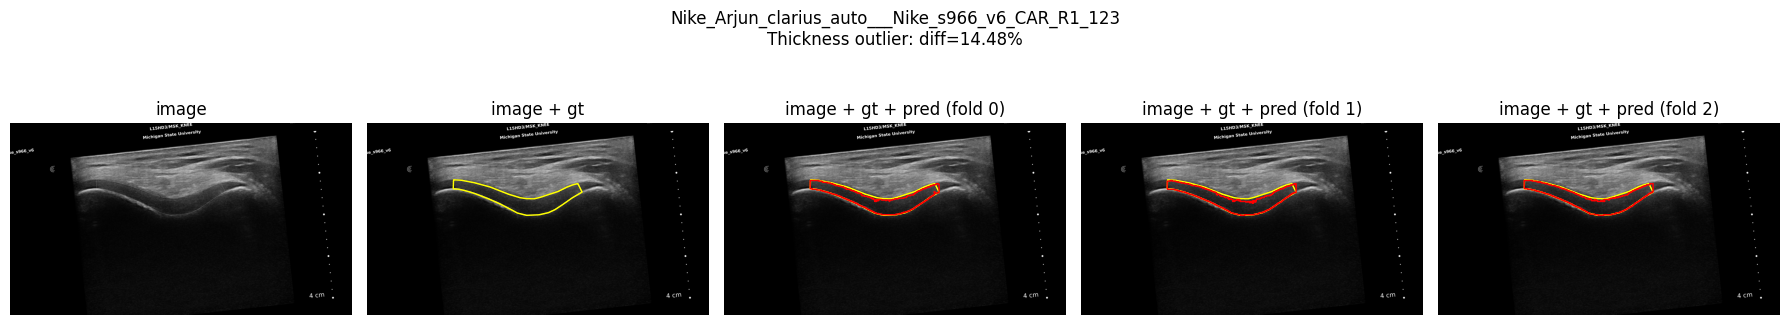

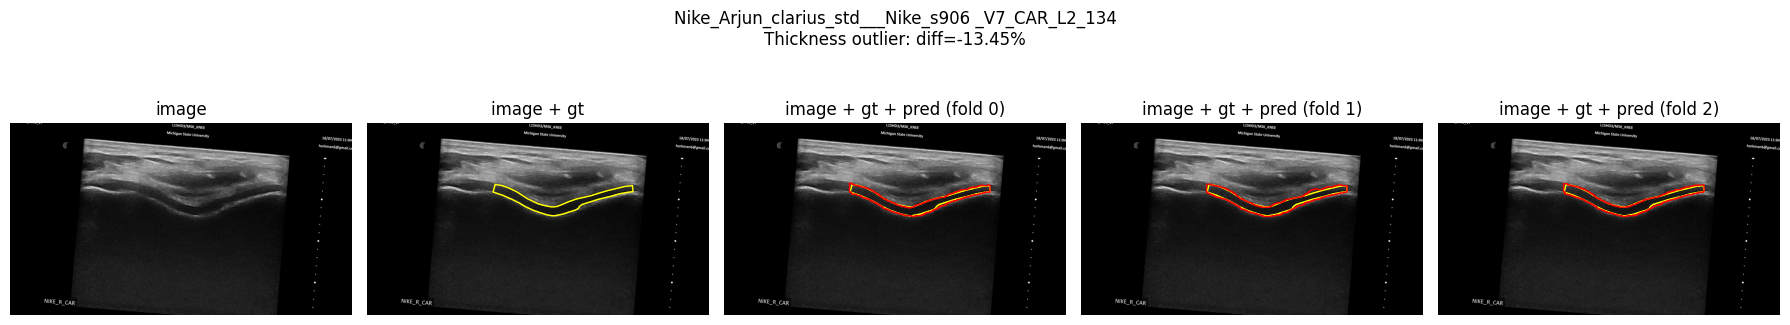

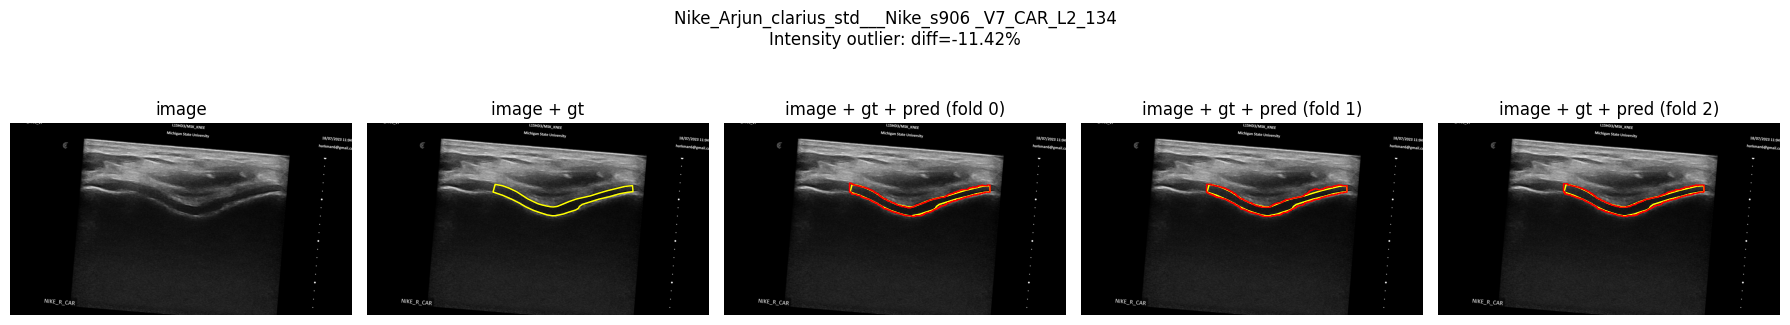

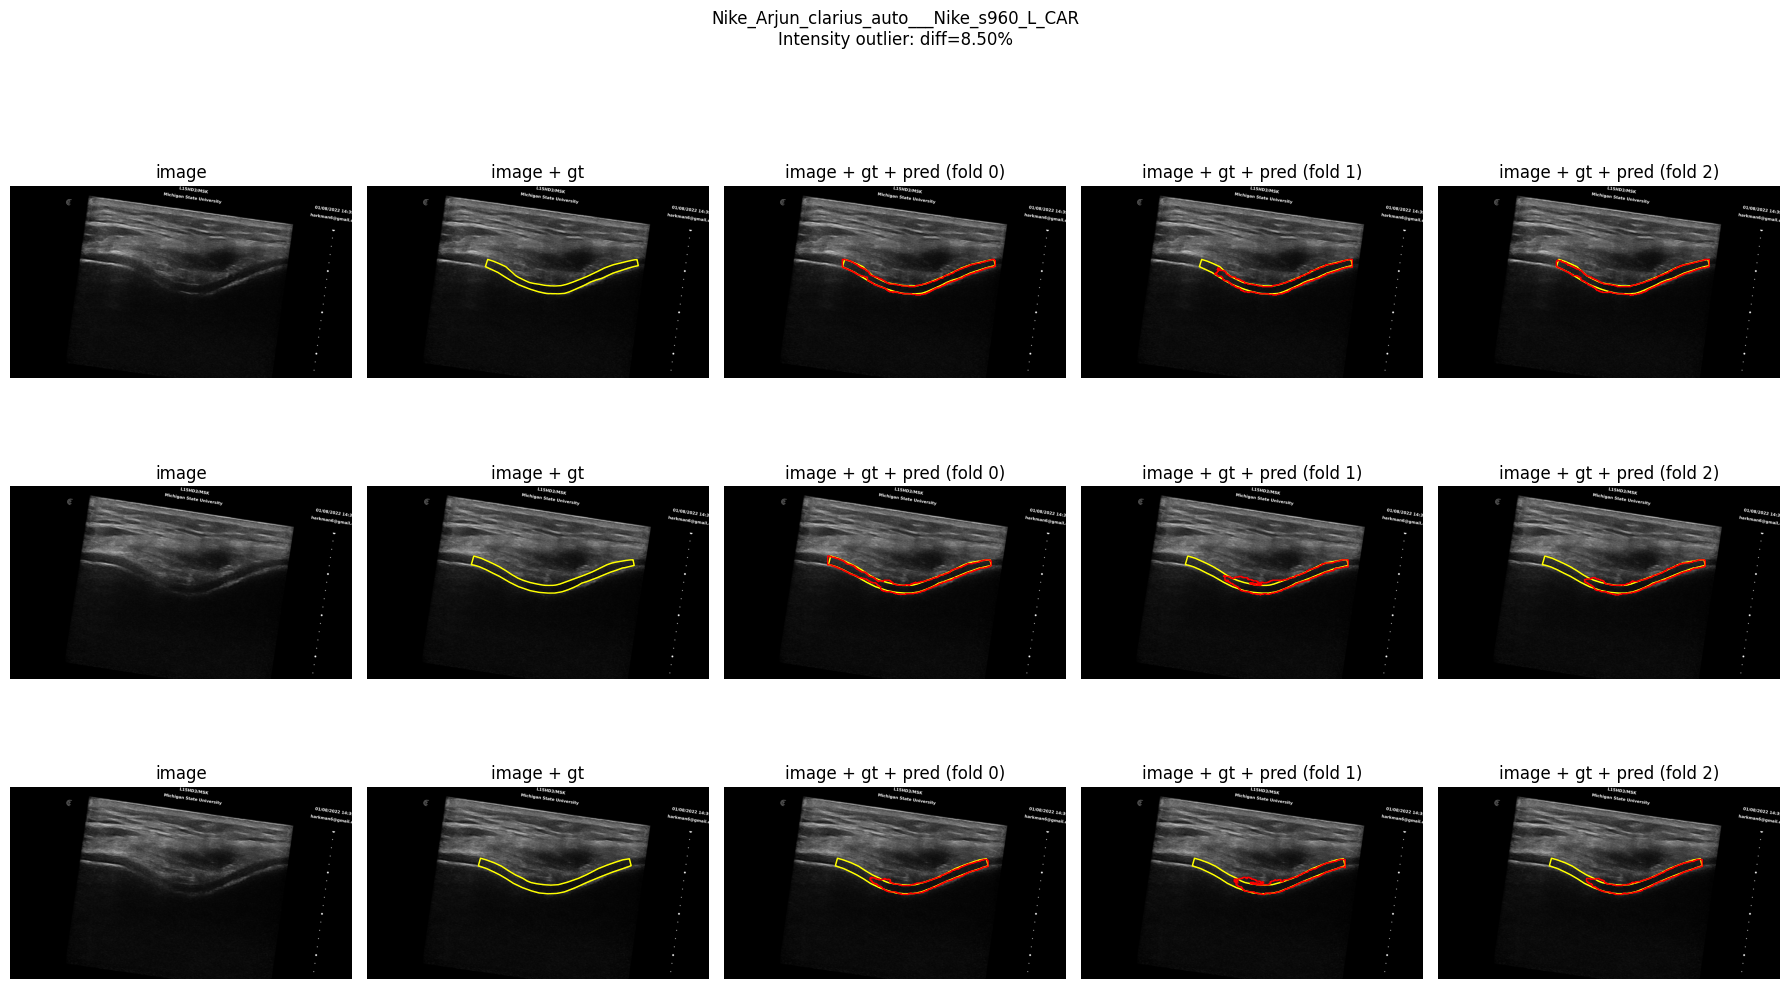

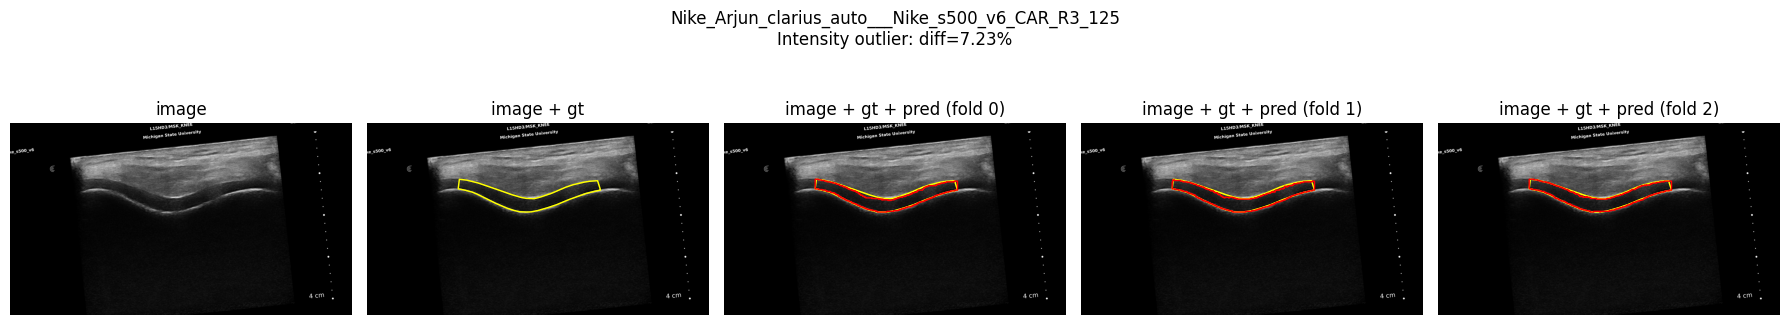

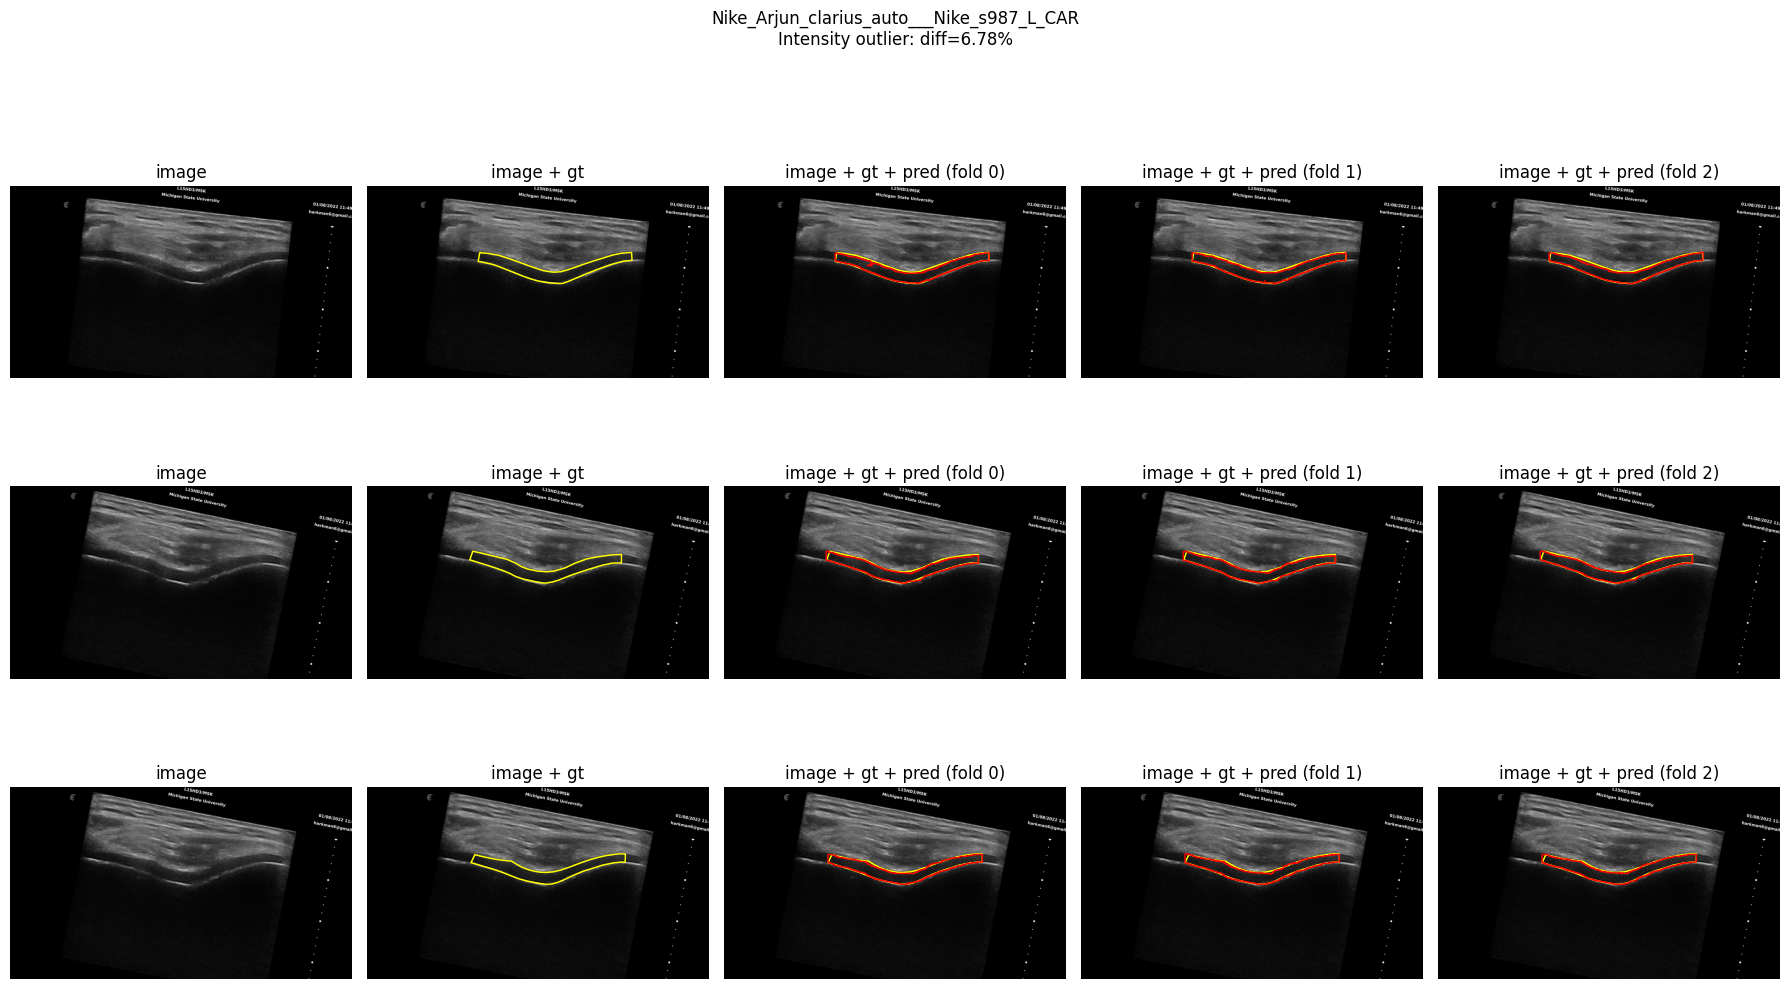

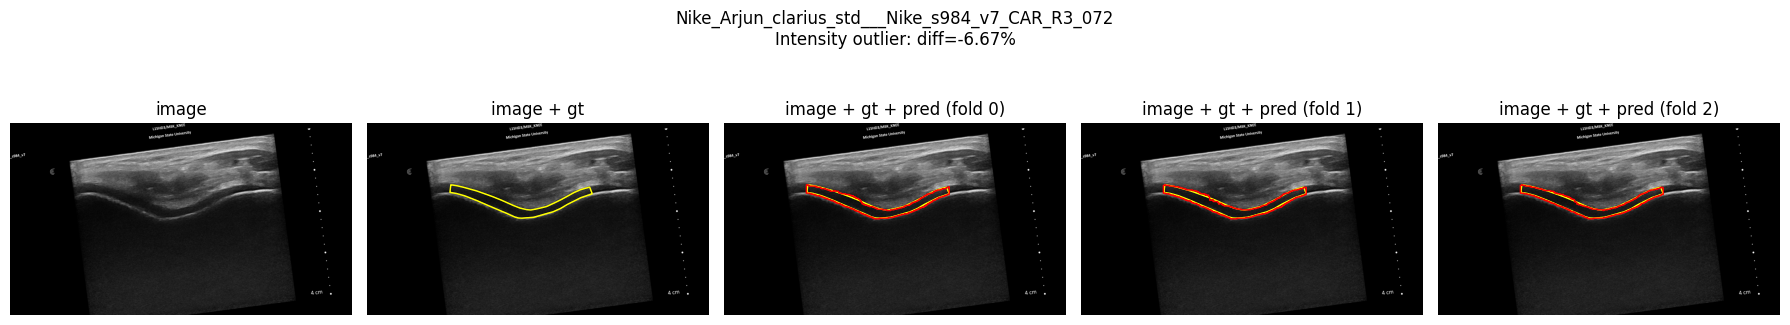

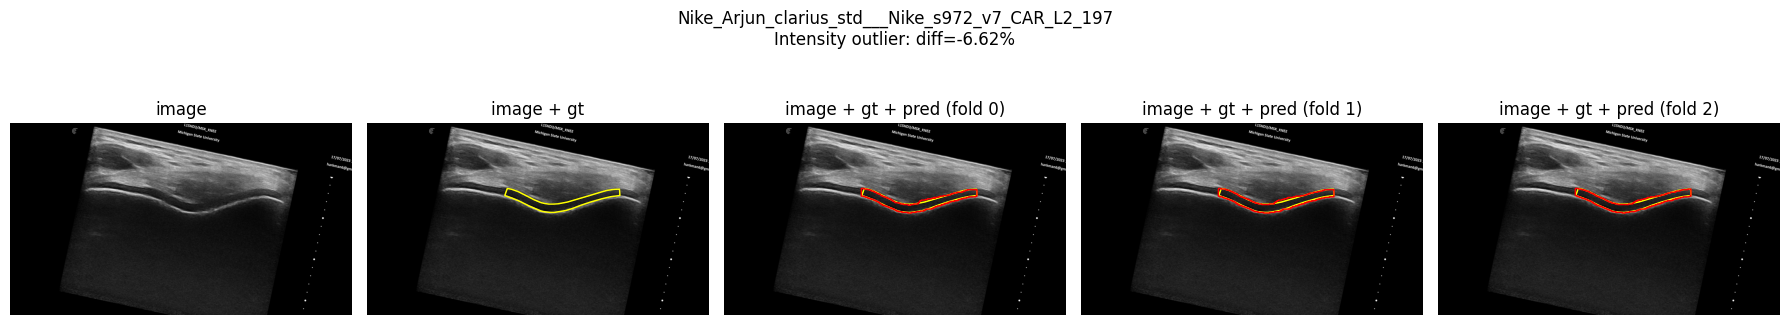

In [16]:
def load_orig_space_prediction(image_id, current_fold):
    preds_dir = f"models/{model}/{train_dataset}/fold_{current_fold}/test/{test_dataset}/preds"
    pred_path = f"{preds_dir}/{image_id}.png"
    if not os.path.exists(pred_path):
        return None

    gt_path = f"{nnUNet_raw}/{test_dataset}/labels{split}/{image_id}.png"

    if test_dataset_id == 79:
        orig_folder = "KneeUS_Ilker"
        orig_fn = image_id
    else:
        orig_folder, orig_fn = image_id.split("___")
    orig_fn = orig_fn.rsplit("_", 1)[0]
    orig_image_path = glob(f"{orig_datasets}/{orig_folder}/images/{orig_fn}*")[0]
    orig_gt_path = glob(f"{orig_datasets}/{orig_folder}/masks/{orig_fn}*")[0]

    pred = binarize_mask(np.array(Image.open(pred_path)))
    gt = binarize_mask(np.array(Image.open(gt_path)))
    gt_in_pred_space = np.array(Image.fromarray(gt.astype(np.uint8)).resize((pred.shape[1], pred.shape[0]), resample=Image.NEAREST))
    orig_image = np.array(Image.open(orig_image_path).convert("L"))
    orig_gt = binarize_mask(np.array(Image.open(orig_gt_path)))
    transform = estimate_mask_transform(gt_in_pred_space, orig_gt)
    orig_pred = apply_mask_transform(pred, transform, orig_image.shape[1], orig_image.shape[0])
    return orig_image, orig_gt, orig_pred


def plot_outlier_subjects(subject_outliers, label, max_images_per_subject=3):
    for _, row in subject_outliers.iterrows():
        case_prefix = row['case_prefix']
        image_rows = outcomes_df[outcomes_df['case_prefix'] == case_prefix].head(max_images_per_subject)
        if len(image_rows) == 0:
            continue

        fig, axes = plt.subplots(len(image_rows), 5, figsize=(18, 3.5 * len(image_rows)))
        if len(image_rows) == 1:
            axes = np.expand_dims(axes, axis=0)
        fig.suptitle(f"{case_prefix}\n{label.title()} outlier: diff={row['diff_pct']:.2f}%", y=1.02)

        for r, (_, image_row) in enumerate(image_rows.iterrows()):
            image_id = image_row['image_id']
            loaded = [load_orig_space_prediction(image_id, current_fold) for current_fold in range(3)]
            loaded = [item for item in loaded if item is not None]
            if len(loaded) == 0:
                for c in range(5):
                    axes[r, c].axis('off')
                continue

            orig_image, orig_gt, _ = loaded[0]

            axes[r, 0].imshow(orig_image, cmap='gray')
            axes[r, 0].set_title('image')
            axes[r, 0].axis('off')

            axes[r, 1].imshow(orig_image, cmap='gray')
            axes[r, 1].contour(orig_gt, levels=[0.5], colors='yellow', linewidths=1)
            axes[r, 1].set_title('image + gt')
            axes[r, 1].axis('off')

            for c in range(3):
                ax = axes[r, c + 2]
                ax.imshow(orig_image, cmap='gray')
                ax.contour(orig_gt, levels=[0.5], colors='yellow', linewidths=1)
                if c < len(loaded):
                    _, _, orig_pred = loaded[c]
                    ax.contour(orig_pred, levels=[0.5], colors='red', linewidths=1)
                    ax.set_title(f'image + gt + pred (fold {c})')
                else:
                    ax.set_title(f'image + gt + pred (fold {c}, missing)')
                ax.axis('off')

        plt.tight_layout()
        plt.show()


plot_outlier_subjects(thickness_outliers, 'thickness')
plot_outlier_subjects(intensity_outliers, 'intensity')


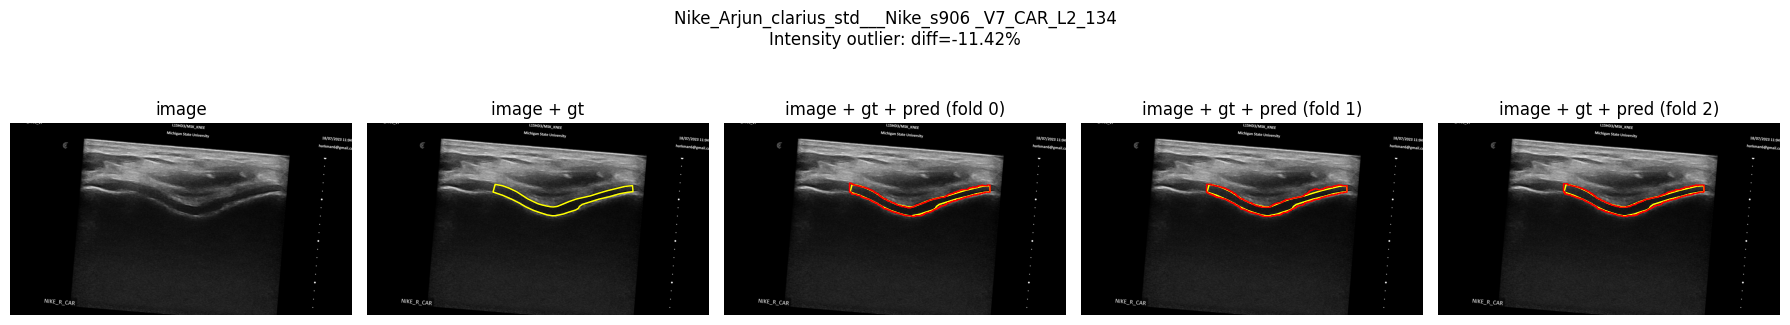

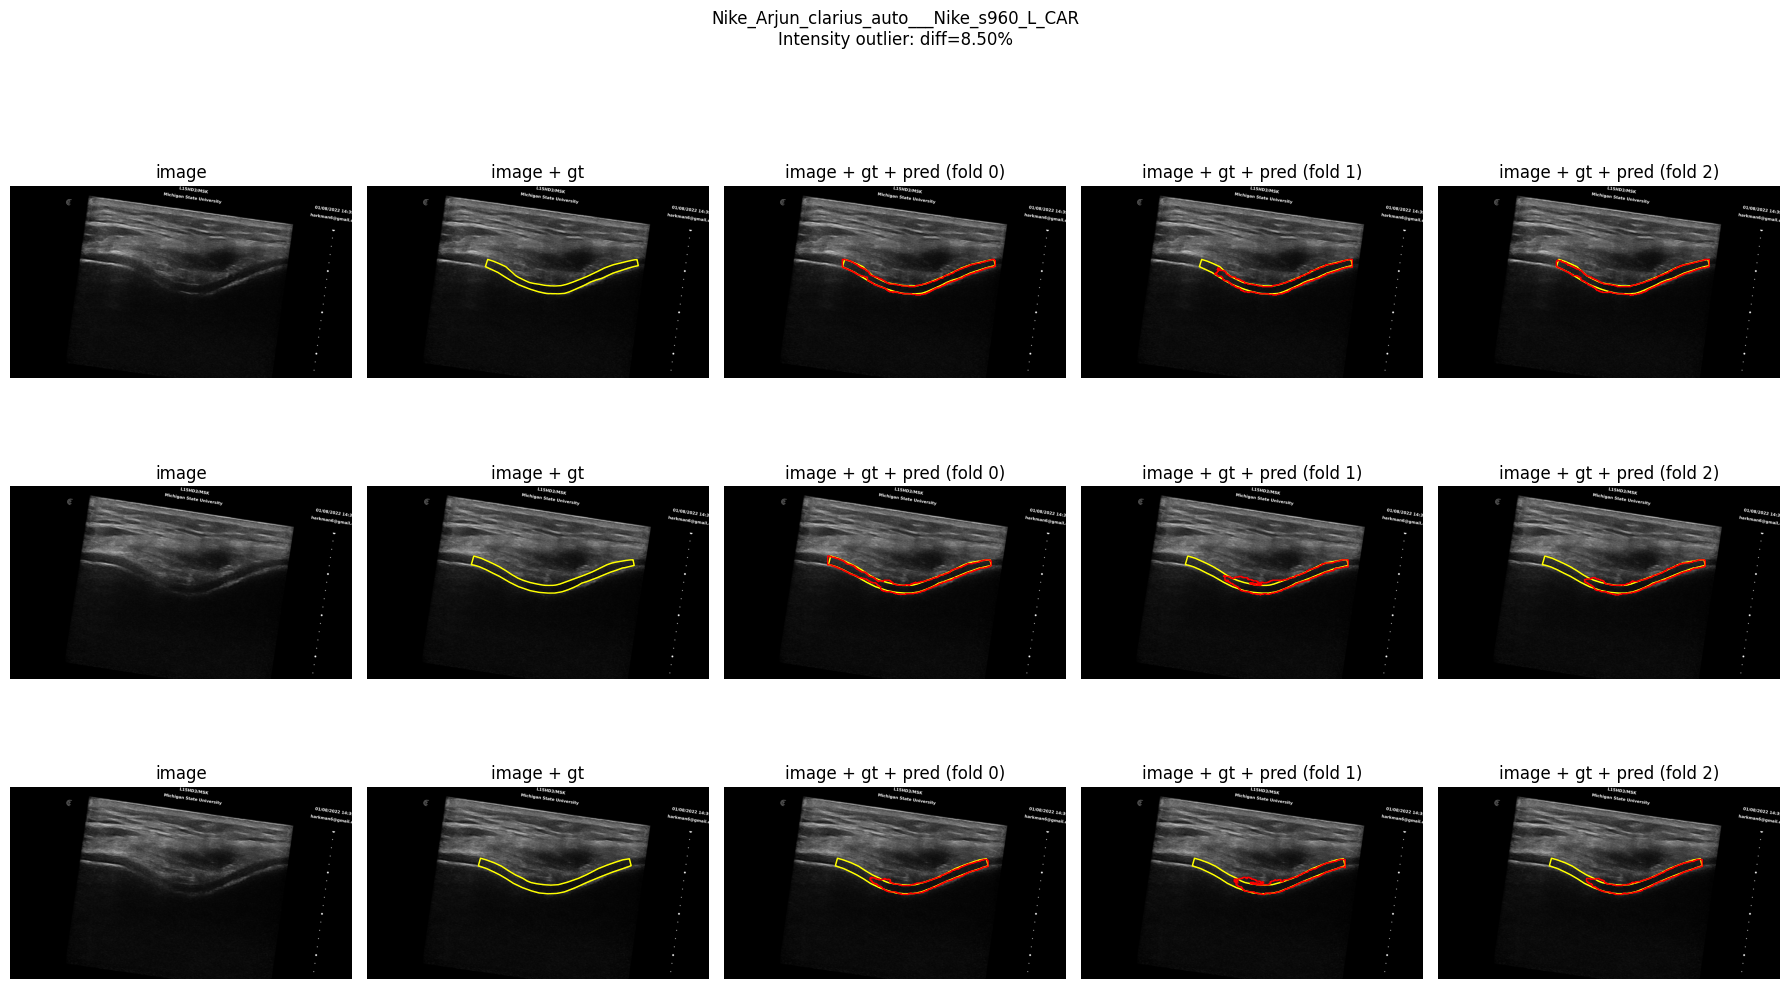

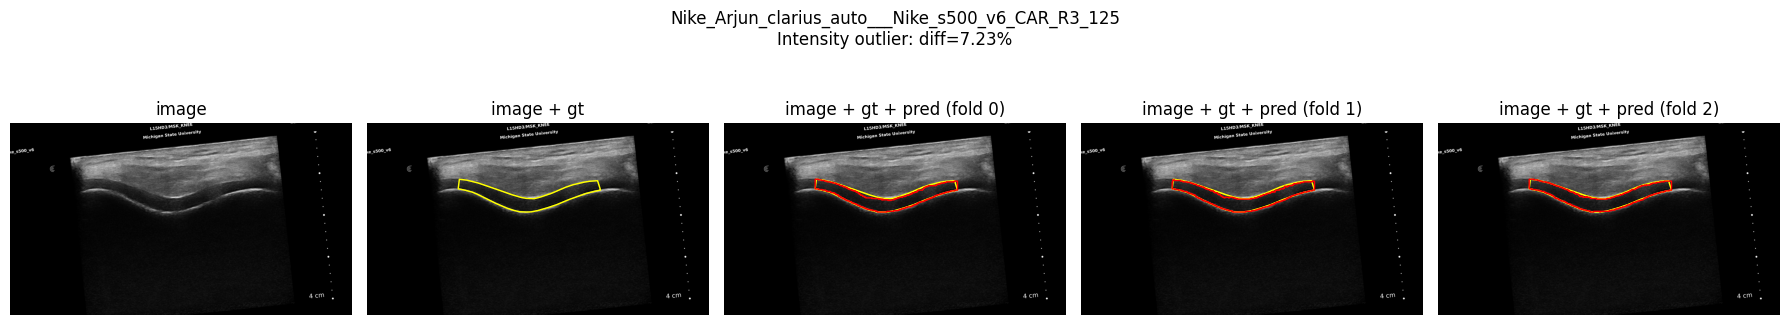

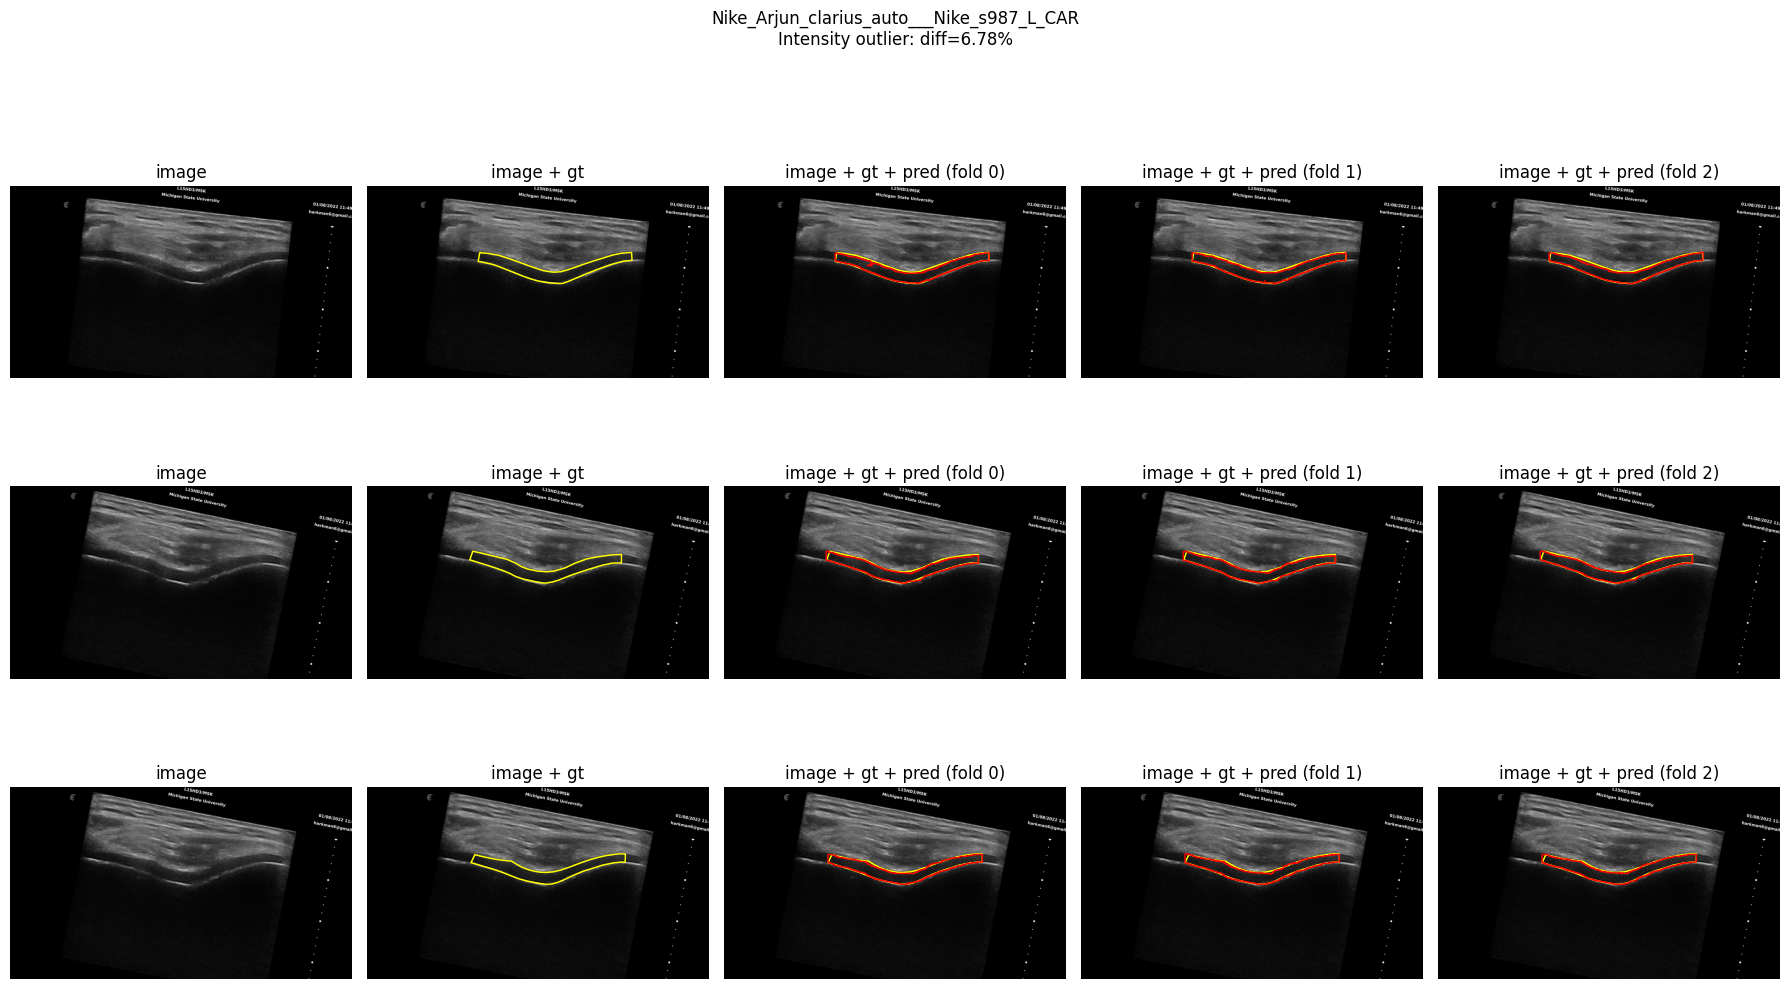

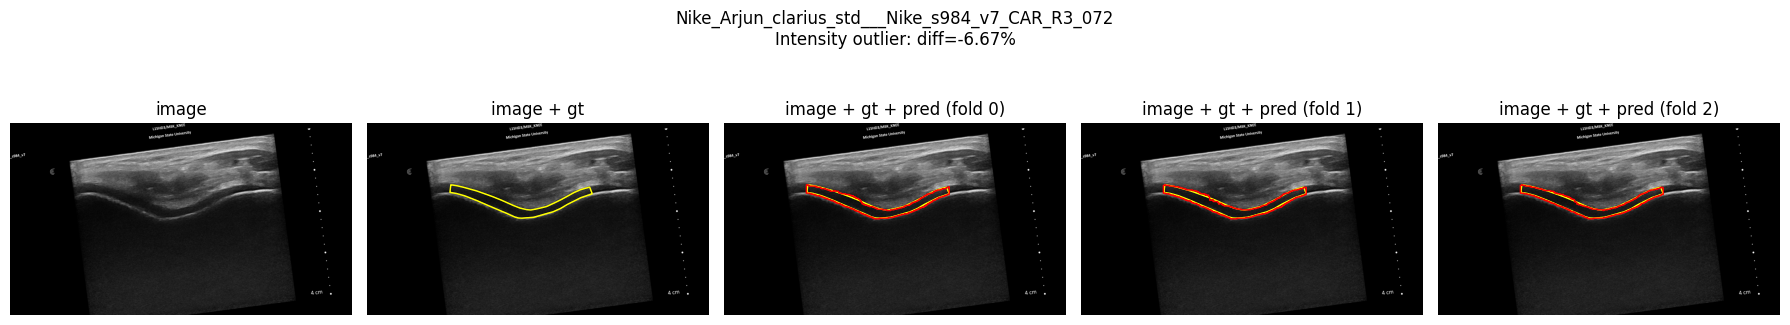

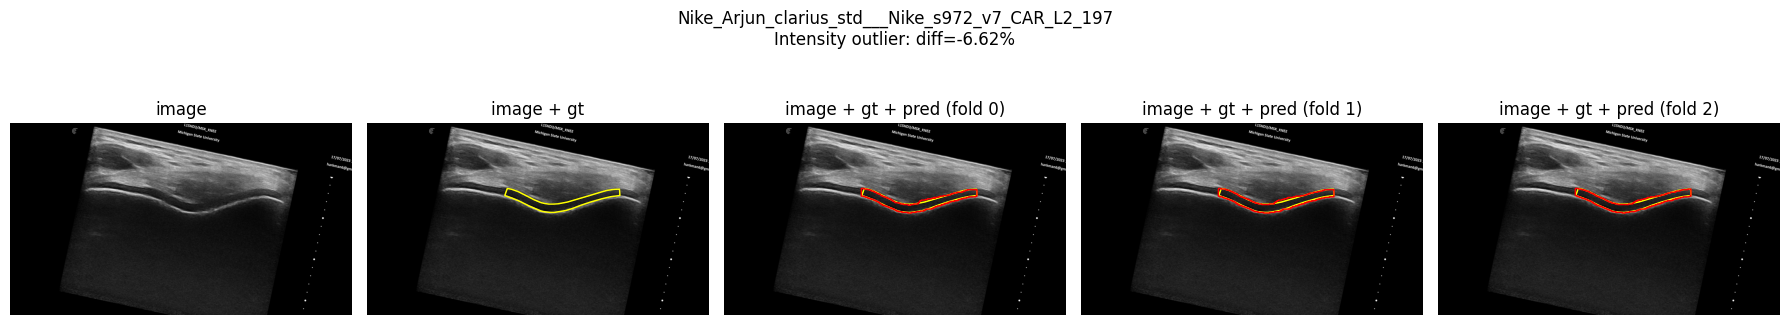

In [17]:
plot_outlier_subjects(intensity_outliers, 'intensity')